In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df = pd.read_csv('fifa_wc.csv')

# EDA

In [3]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [4]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [5]:
df.shape

(54600, 75)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [7]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

In [8]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [9]:
df.dtypes

player_id                    object
player_name                  object
age                           int64
nationality                  object
team                         object
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

In [10]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

player_id                   0.0
player_name                 0.0
age                         0.0
nationality                 0.0
team                        0.0
                           ... 
total_goals_tournament      0.0
total_assists_tournament    0.0
total_minutes_tournament    0.0
player_of_match_awards      0.0
tournament_rating           0.0
Length: 75, dtype: float64

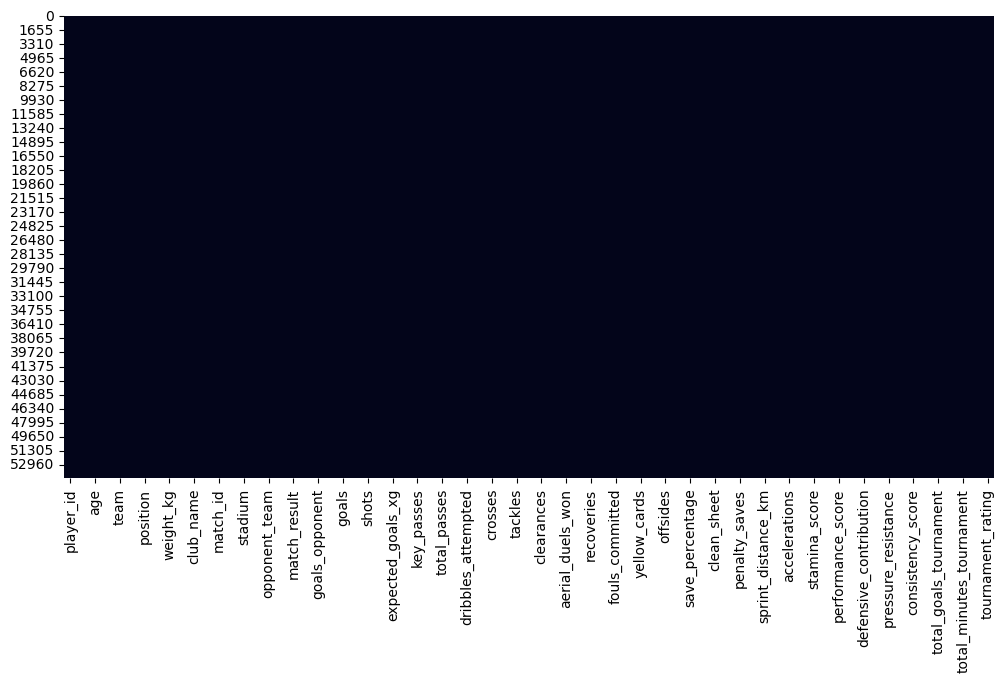

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(54600, 75)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(54600, 75)

In [16]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

# Creating Target Variable

In [17]:
 # Create Target Variable
# Convert performance score into classification target.
median_score = df['performance_score'].median()

In [18]:
median_score

54.1

In [19]:
df['high_performer'] = (
    df['performance_score'] > median_score
).astype(int)

In [20]:
df['high_performer'].value_counts()

high_performer
0    27346
1    27254
Name: count, dtype: int64

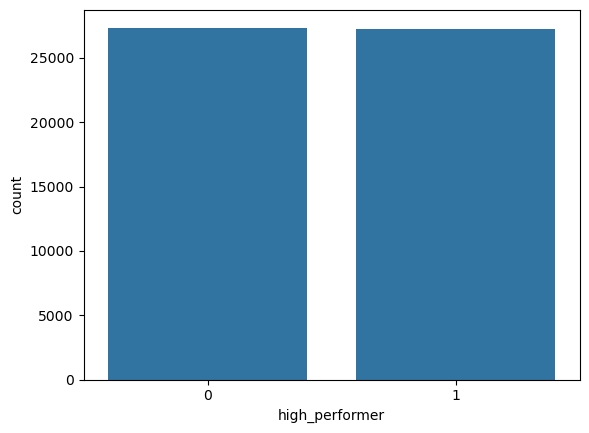

In [21]:
sns.countplot(x='high_performer', data=df)

plt.show()

# Numerical Feature Analysis

In [22]:
# Numerical Feature Analysis
# Separate Numerical Columns

num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh',
       'accelerations', 'decelerations', 'stamina_score', 'player_rating',
       'performance_score', 'offensive_contribution', 'defensive_contribution',
       'possession_impact', 'pressure_resistance', 'c

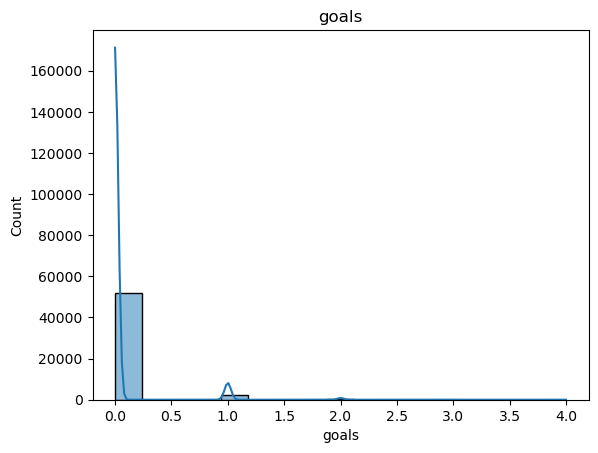

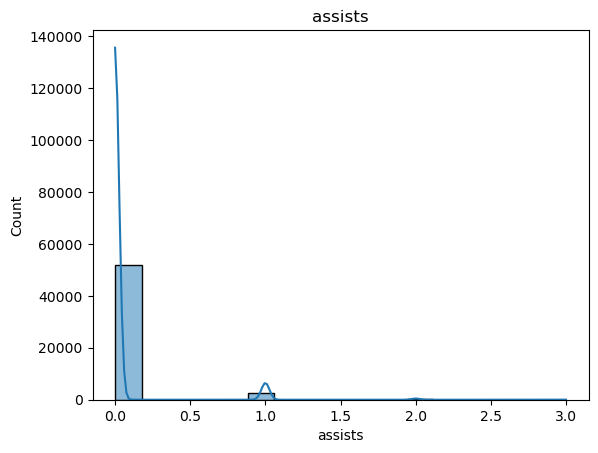

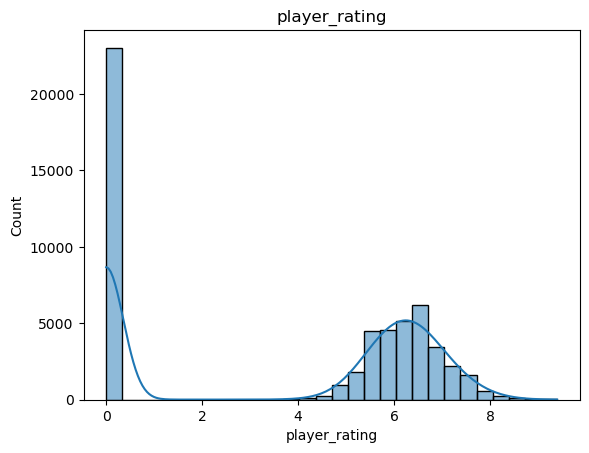

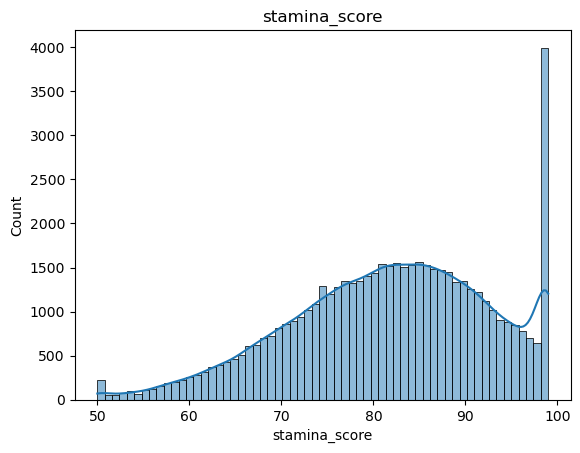

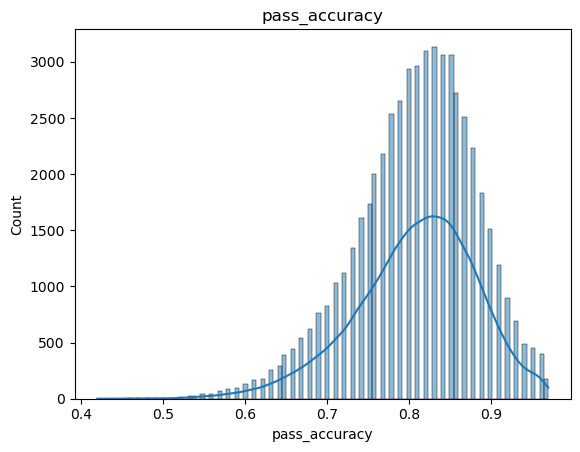

In [23]:
important_cols = [
    'goals',
    'assists',
    'player_rating',
    'stamina_score',
    'pass_accuracy'
]

for col in important_cols:

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

# Outlier Detection

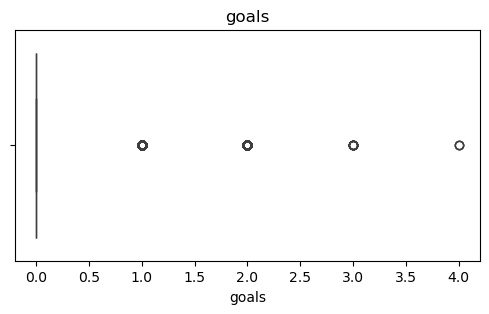

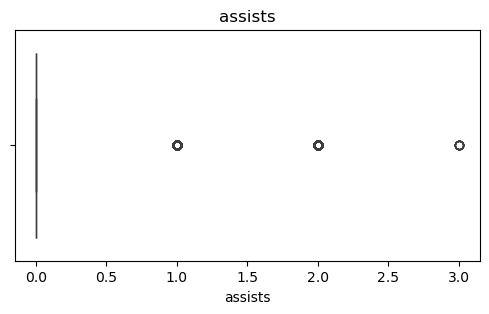

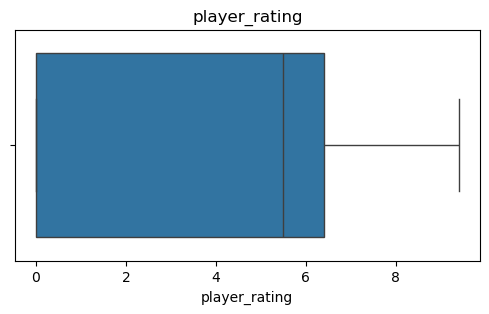

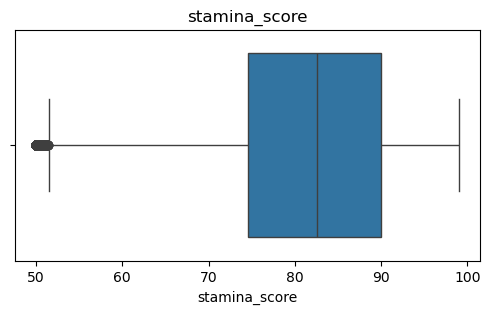

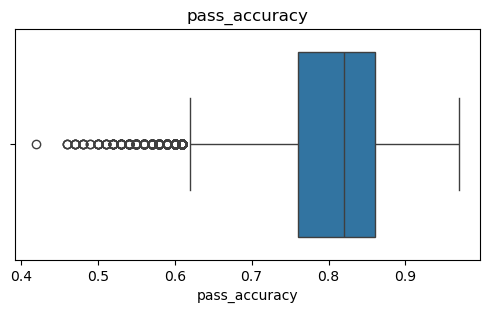

In [24]:
for col in important_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

# Categorical Analysis

In [25]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result'],
      dtype='object')

In [26]:
# Unique Values
for col in cat_cols:

    print(col)

    print(df[col].nunique())

    print("-"*50)

player_id
1248
--------------------------------------------------
player_name
1245
--------------------------------------------------
nationality
48
--------------------------------------------------
team
48
--------------------------------------------------
position
4
--------------------------------------------------
preferred_foot
2
--------------------------------------------------
club_name
122
--------------------------------------------------
match_id
1050
--------------------------------------------------
match_date
51
--------------------------------------------------
stadium
16
--------------------------------------------------
city
16
--------------------------------------------------
opponent_team
48
--------------------------------------------------
tournament_stage
7
--------------------------------------------------
match_result
3
--------------------------------------------------


In [27]:
# Top Nationalities
df['nationality'].value_counts().head(10)

nationality
Qatari      1716
Jamaican    1534
Moroccan    1430
Dutch       1404
Italian     1378
Saudi       1352
Belgian     1326
Turkish     1300
Croatian    1274
Scottish    1274
Name: count, dtype: int64

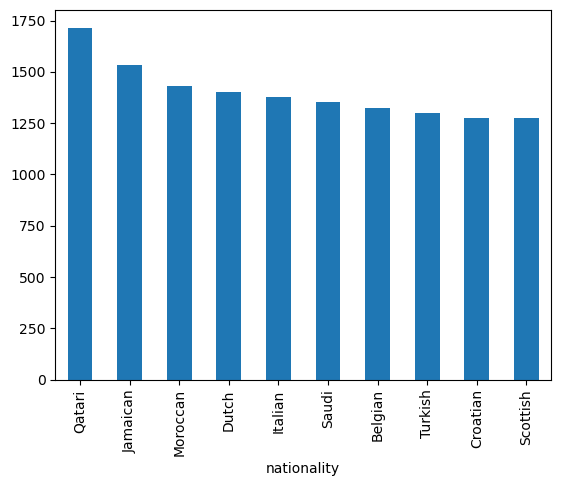

In [28]:
df['nationality'].value_counts().head(10).plot(
    kind='bar'
)

plt.show()

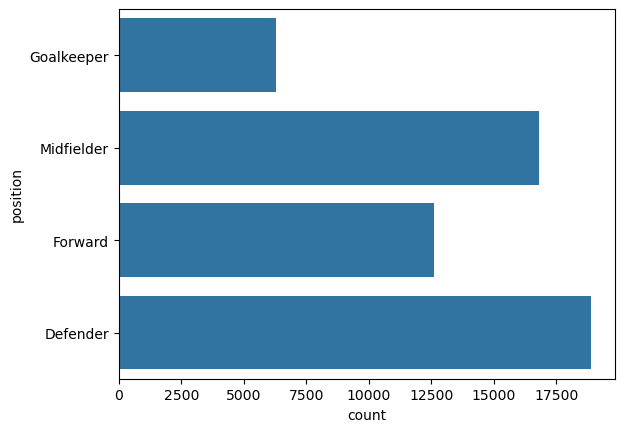

In [29]:
# Position Distribution

sns.countplot(
    y='position',
    data=df
)

plt.show()

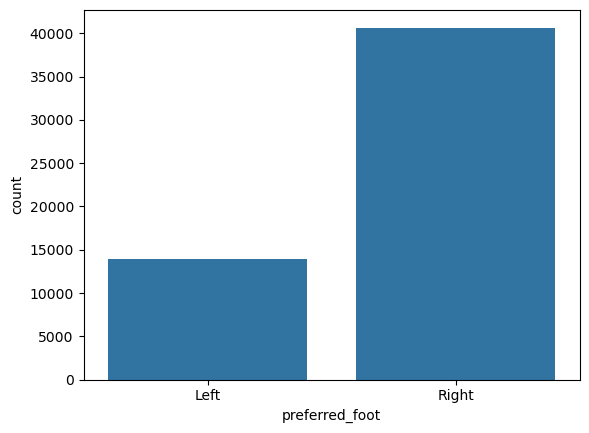

In [30]:
# Preferred Foot

sns.countplot(
    x='preferred_foot',
    data=df
)

plt.show()

# Correlation Analysis

In [31]:
corr = df[num_cols].corr()

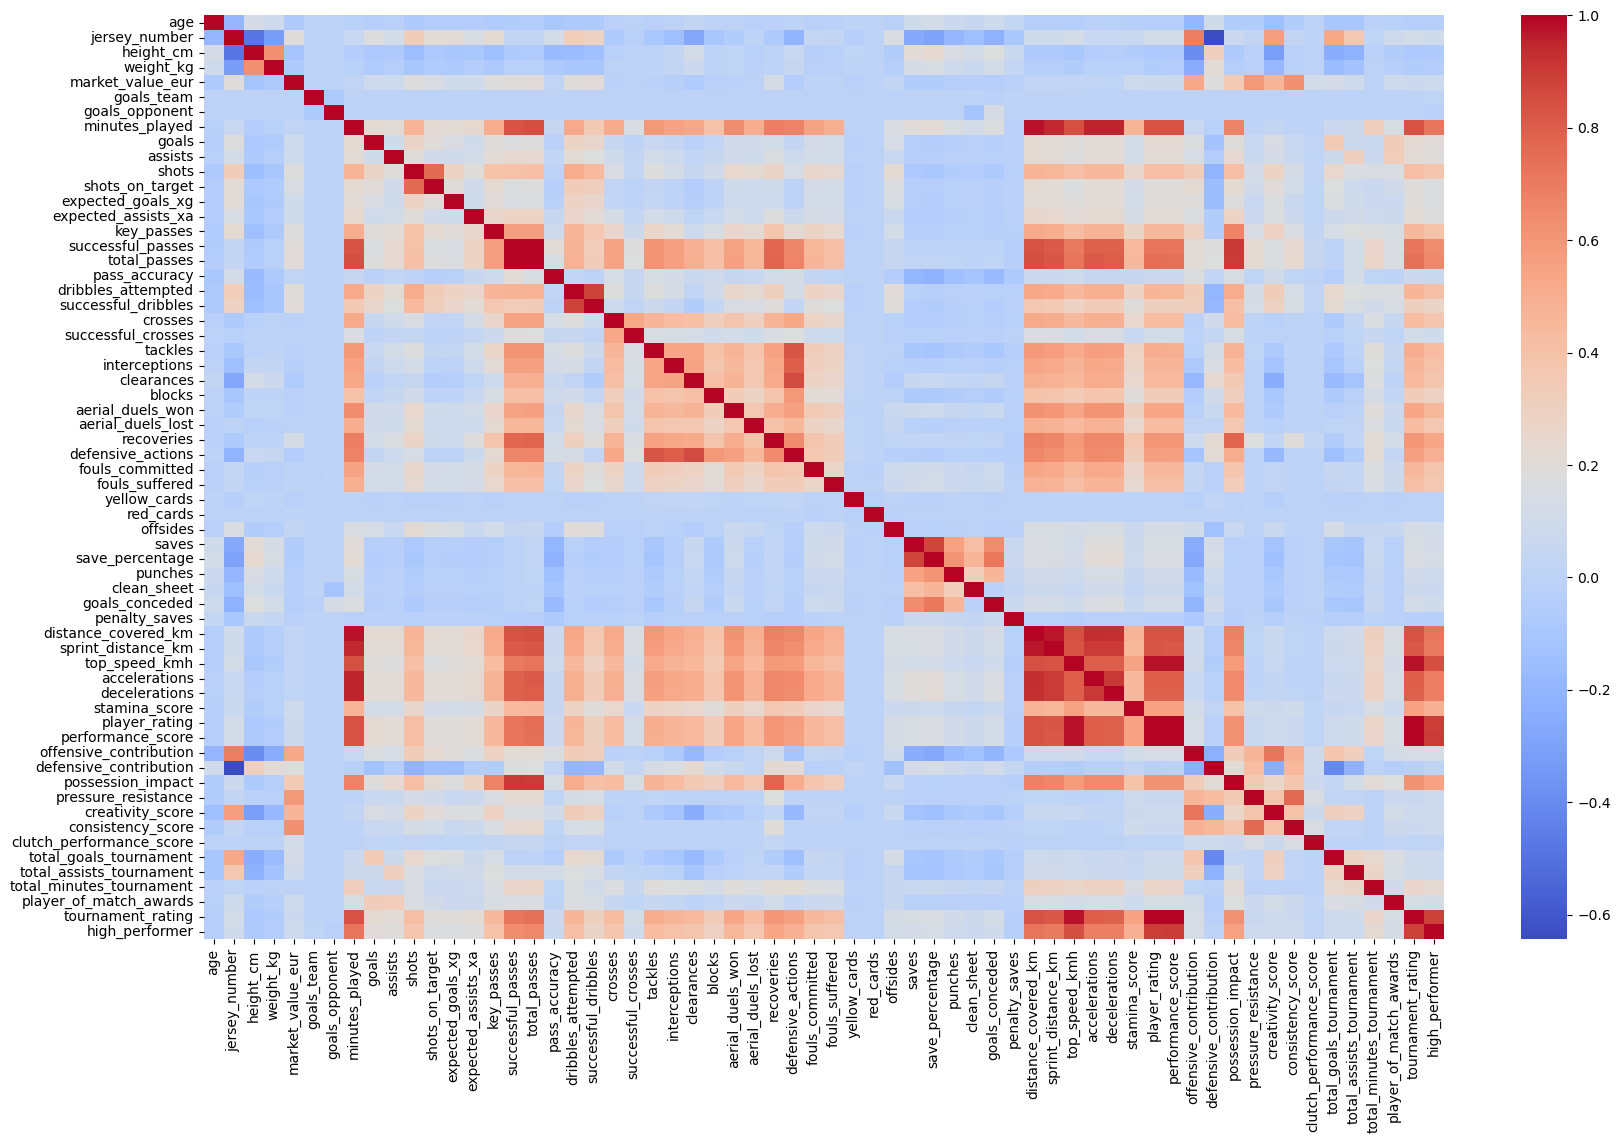

In [32]:
plt.figure(figsize=(20,12))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

# Correlation With Target

In [33]:
df.corr(numeric_only=True)

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating,high_performer
age,1.000000,-0.191316,0.124882,0.093327,-0.068914,-6.428752e-03,1.683938e-03,-0.022833,-0.036548,-0.027272,...,-0.055096,-0.147483,-0.057637,-0.006452,-0.099839,-0.098019,-0.011190,-0.025517,-0.038990,-0.036800
jersey_number,-0.191316,1.000000,-0.486071,-0.319660,0.187251,4.453502e-17,4.339367e-17,0.061657,0.182235,0.110867,...,0.034995,0.568534,0.034015,0.008626,0.526784,0.364273,0.014613,0.090411,0.110570,0.098774
height_cm,0.124882,-0.486071,1.000000,0.630950,-0.112356,2.419965e-03,-4.297944e-03,-0.041854,-0.081591,-0.068021,...,-0.013760,-0.314955,-0.018848,-0.001603,-0.244723,-0.224186,-0.010504,-0.047627,-0.079246,-0.068650
weight_kg,0.093327,-0.319660,0.630950,1.000000,-0.073950,-6.431085e-03,1.289886e-03,-0.021524,-0.060550,-0.039387,...,-0.019334,-0.184050,-0.021363,-0.000473,-0.168261,-0.127640,-0.001755,-0.033163,-0.047990,-0.042835
market_value_eur,-0.068914,0.187251,-0.112356,-0.073950,1.000000,-3.511289e-03,1.612354e-03,0.017773,0.093392,0.081924,...,0.594907,0.466853,0.624168,0.111797,0.121565,0.088259,0.000860,0.088152,0.074993,0.082191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
total_assists_tournament,-0.098019,0.364273,-0.224186,-0.127640,0.088259,-3.486700e-03,-2.818644e-03,0.079970,0.077165,0.307885,...,0.030114,0.296283,0.024850,0.009065,0.278294,1.000000,0.272720,0.141938,0.097110,0.086489
total_minutes_tournament,-0.011190,0.014613,-0.010504,-0.001755,0.000860,-2.085579e-03,-3.046484e-03,0.312868,0.064891,0.069086,...,-0.000315,0.007218,-0.001877,-0.000082,0.241801,0.272720,1.000000,0.102657,0.260638,0.223978
player_of_match_awards,-0.025517,0.090411,-0.047627,-0.033163,0.088152,3.695465e-04,-1.793868e-03,0.143611,0.324354,0.327383,...,0.072808,0.110730,0.077475,0.024091,0.155998,0.141938,0.102657,1.000000,0.144761,0.132213
tournament_rating,-0.038990,0.110570,-0.079246,-0.047990,0.074993,8.611773e-03,-7.207199e-03,0.835092,0.216853,0.203989,...,0.065343,0.086443,0.070183,0.013002,0.091238,0.097110,0.260638,0.144761,1.000000,0.889990


In [34]:
corr_target = df.corr(numeric_only=True)['high_performer']

In [35]:
corr_target.sort_values(
    ascending=False
)

high_performer       1.000000
performance_score    0.899615
player_rating        0.892160
tournament_rating    0.889990
top_speed_kmh        0.849606
                       ...   
goals_opponent      -0.017450
penalty_saves       -0.030407
age                 -0.036800
weight_kg           -0.042835
height_cm           -0.068650
Name: high_performer, Length: 62, dtype: float64

In [36]:
corr_target.sort_values(
    ascending=False
).head(15)

high_performer         1.000000
performance_score      0.899615
player_rating          0.892160
tournament_rating      0.889990
top_speed_kmh          0.849606
distance_covered_km    0.723885
minutes_played         0.723725
sprint_distance_km     0.709602
accelerations          0.690105
decelerations          0.687569
total_passes           0.656451
successful_passes      0.639795
possession_impact      0.556305
recoveries             0.531686
stamina_score          0.488478
Name: high_performer, dtype: float64

# Compare Features vs Target

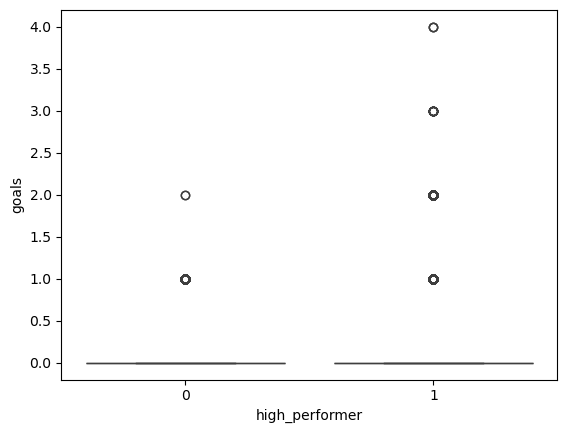

In [37]:
# Goals vs High Performer

sns.boxplot(
    x='high_performer',
    y='goals',
    data=df
)

plt.show()

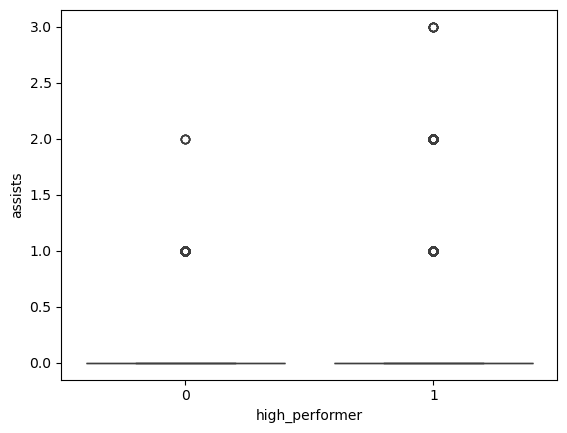

In [38]:
# Assists vs High Performer

sns.boxplot(
    x='high_performer',
    y='assists',
    data=df
)

plt.show()

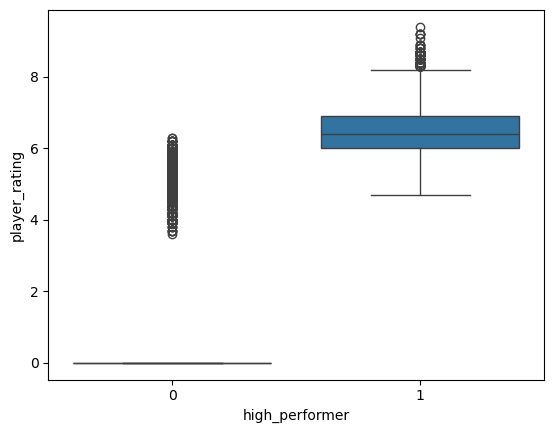

In [39]:
# Player Rating vs High Performer

sns.boxplot(
    x='high_performer',
    y='player_rating',
    data=df
)

plt.show()

# Feature Selection

**Remove Leakage Columns
<br>
Since your target is derived from `performance_score`, remove columns that directly reveal it:**

In [40]:
cols = [
    'offensive_contribution',
    'defensive_contribution',
    'possession_impact',
    'creativity_score',
    'consistency_score',
    'clutch_performance_score'
]

df[cols + ['performance_score']].corr()['performance_score']

offensive_contribution      0.136697
defensive_contribution     -0.014364
possession_impact           0.618847
creativity_score            0.086902
consistency_score           0.071934
clutch_performance_score    0.013340
performance_score           1.000000
Name: performance_score, dtype: float64

In [41]:
drop_cols = [
    # IDs
    'player_id',
    'player_name',
    'match_id',

    # Leakage
    'performance_score',
    'player_rating',
    'tournament_rating'
]

df = df.drop(columns=drop_cols)

In [42]:
df.head()

,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,high_performer
0,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,0
1,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,1
2,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,1
3,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,1
4,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,1


In [43]:
df.columns

Index(['age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm',
       'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur',
       'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage',
       'match_result', 'goals_team', 'goals_opponent', 'minutes_played',
       'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg',
       'expected_assists_xa', 'key_passes', 'successful_passes',
       'total_passes', 'pass_accuracy', 'dribbles_attempted',
       'successful_dribbles', 'crosses', 'successful_crosses', 'tackles',
       'interceptions', 'clearances', 'blocks', 'aerial_duels_won',
       'aerial_duels_lost', 'recoveries', 'defensive_actions',
       'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards',
       'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet',
       'goals_conceded', 'penalty_saves', 'distance_covered_km',
       'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations',
 

In [44]:
drop_cols = [

    # Future tournament statistics
    'total_goals_tournament',
    'total_assists_tournament',
    'total_minutes_tournament',
    'player_of_match_awards'
]

df = df.drop(columns=drop_cols)

In [45]:
df.head()

,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,...,decelerations,stamina_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,high_performer
0,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,...,23,81.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0
1,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,...,17,85.5,37.9,29.4,3.5,38.2,43.7,31.1,52.7,1
2,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,...,19,88.8,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1
3,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,...,19,89.2,47.3,6.9,1.2,19.8,42.3,40.9,78.5,1
4,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,...,18,73.6,33.0,75.6,6.2,44.1,33.5,60.0,56.6,1


**This code scans the correlation matrix and returns all pairs of numeric columns whose correlation magnitude exceeds 0.9, helping you identify redundant features and avoid `multicollinearity/data` leakage before building your ML model.**

In [46]:
corr_matrix = df.corr(numeric_only=True)

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append(
                (corr_matrix.columns[i],
                 corr_matrix.columns[j],
                 corr_matrix.iloc[i, j])
            )

high_corr

[('total_passes', 'successful_passes', np.float64(0.9947816111717686)),
 ('distance_covered_km', 'minutes_played', np.float64(0.9772819000928805)),
 ('sprint_distance_km', 'minutes_played', np.float64(0.9466794715645912)),
 ('sprint_distance_km', 'distance_covered_km', np.float64(0.9692012972112886)),
 ('accelerations', 'minutes_played', np.float64(0.9539443922708617)),
 ('accelerations', 'distance_covered_km', np.float64(0.9325075594329355)),
 ('accelerations', 'sprint_distance_km', np.float64(0.9030478085117039)),
 ('decelerations', 'minutes_played', np.float64(0.9489039640256747)),
 ('decelerations', 'distance_covered_km', np.float64(0.9276672970109106)),
 ('decelerations', 'accelerations', np.float64(0.9052584483140884)),
 ('possession_impact', 'successful_passes', np.float64(0.9042376270692931)),
 ('possession_impact', 'total_passes', np.float64(0.9036044091194777))]

In [47]:
drop_cols = [
  
    # Multicollinearity
    'total_passes',
    'sprint_distance_km',
    'accelerations',
    'decelerations',
    'possession_impact'
]

df = df.drop(columns=drop_cols)

In [48]:
df.head()

,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,...,distance_covered_km,top_speed_kmh,stamina_score,offensive_contribution,defensive_contribution,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,high_performer
0,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,...,7.8,26.5,81.9,3.3,48.2,44.2,55.9,42.0,51.8,0
1,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,...,10.4,29.0,85.5,37.9,29.4,38.2,43.7,31.1,52.7,1
2,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,...,8.8,33.7,88.8,79.8,78.6,99.0,99.0,83.4,54.8,1
3,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,...,9.6,32.1,89.2,47.3,6.9,19.8,42.3,40.9,78.5,1
4,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,...,7.5,30.5,73.6,33.0,75.6,44.1,33.5,60.0,56.6,1


# Next EDA Tasks 

In [49]:
# Missing Values
df.isnull().sum().sort_values(ascending=False)

age                         0
nationality                 0
team                        0
jersey_number               0
position                    0
                           ..
pressure_resistance         0
creativity_score            0
consistency_score           0
clutch_performance_score    0
high_performer              0
Length: 61, dtype: int64

In [50]:
# Check Class Balance
df['high_performer'].value_counts()

high_performer
0    27346
1    27254
Name: count, dtype: int64

In [51]:
df['high_performer'].value_counts(normalize=True)*100

high_performer
0    50.084249
1    49.915751
Name: proportion, dtype: float64

In [52]:
# Categorical Columns
df.select_dtypes(include='object').columns

Index(['nationality', 'team', 'position', 'preferred_foot', 'club_name',
       'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage',
       'match_result'],
      dtype='object')

In [53]:
# Cardinality Check
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].nunique())

nationality 48
team 48
position 4
preferred_foot 2
club_name 122
match_date 51
stadium 16
city 16
opponent_team 48
tournament_stage 7
match_result 3


In [54]:
# 1. Drop club_name
df.drop(columns=['club_name'], inplace=True)

In [55]:
# 2. Handle match_date
df['match_date'].head()

0    2026-07-10
1    2026-07-10
2    2026-07-10
3    2026-07-10
4    2026-07-10
Name: match_date, dtype: object

In [56]:
df['match_date'] = pd.to_datetime(df['match_date'])

In [57]:
df['match_date']

0       2026-07-10
1       2026-07-10
2       2026-07-10
3       2026-07-10
4       2026-07-10
           ...    
54595   2026-07-24
54596   2026-07-24
54597   2026-07-24
54598   2026-07-24
54599   2026-07-24
Name: match_date, Length: 54600, dtype: datetime64[ns]

In [58]:
df['match_month'] = df['match_date'].dt.month
df['match_day'] = df['match_date'].dt.day

In [59]:
df.drop(columns=['match_date'], inplace=True)

# Encoding

In [60]:
df['preferred_foot'] = df['preferred_foot'].map({
    'Right': 1,
    'Left': 0
})

In [61]:
df['preferred_foot']

0        0
1        1
2        0
3        1
4        0
        ..
54595    1
54596    1
54597    0
54598    1
54599    1
Name: preferred_foot, Length: 54600, dtype: int64

In [62]:
# Use One-Hot Encoding:

df = pd.get_dummies(
    df,
    columns=[
        'nationality',
        'team',
        'position',
        'stadium',
        'city',
        'opponent_team',
        'tournament_stage',
        'match_result'
    ],
    drop_first=True
)

In [63]:
df.head()

,age,jersey_number,height_cm,weight_kg,preferred_foot,market_value_eur,goals_team,goals_opponent,minutes_played,goals,...,opponent_team_Uruguay,opponent_team_Uzbekistan,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
0,26,3,195,75,0,4384884,1,0,72,0,...,False,False,True,False,False,False,False,False,False,True
1,19,18,178,75,1,4918927,1,0,90,0,...,False,False,True,False,False,False,False,False,False,True
2,18,14,177,72,0,125015698,1,0,73,1,...,False,False,True,False,False,False,False,False,False,True
3,20,21,182,74,1,11805512,1,0,80,1,...,False,False,True,False,False,False,False,False,False,True
4,23,7,191,81,0,13325174,1,0,79,0,...,False,False,True,False,False,False,False,False,False,True


In [64]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [65]:
df.head()

,age,jersey_number,height_cm,weight_kg,preferred_foot,market_value_eur,goals_team,goals_opponent,minutes_played,goals,...,opponent_team_Uruguay,opponent_team_Uzbekistan,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
0,26,3,195,75,0,4384884,1,0,72,0,...,0,0,1,0,0,0,0,0,0,1
1,19,18,178,75,1,4918927,1,0,90,0,...,0,0,1,0,0,0,0,0,0,1
2,18,14,177,72,0,125015698,1,0,73,1,...,0,0,1,0,0,0,0,0,0,1
3,20,21,182,74,1,11805512,1,0,80,1,...,0,0,1,0,0,0,0,0,0,1
4,23,7,191,81,0,13325174,1,0,79,0,...,0,0,1,0,0,0,0,0,0,1


In [66]:
df.to_csv("fifa_cleaned.csv", index=False)

In [67]:
cleaned_df = pd.read_csv("fifa_cleaned.csv")

In [68]:
cleaned_df

,age,jersey_number,height_cm,weight_kg,preferred_foot,market_value_eur,goals_team,goals_opponent,minutes_played,goals,...,opponent_team_Uruguay,opponent_team_Uzbekistan,tournament_stage_Group Stage,tournament_stage_Quarter Finals,tournament_stage_Round of 16,tournament_stage_Round of 32,tournament_stage_Semi Finals,tournament_stage_Third Place Match,match_result_L,match_result_W
0,26,3,195,75,0,4384884,1,0,72,0,...,0,0,1,0,0,0,0,0,0,1
1,19,18,178,75,1,4918927,1,0,90,0,...,0,0,1,0,0,0,0,0,0,1
2,18,14,177,72,0,125015698,1,0,73,1,...,0,0,1,0,0,0,0,0,0,1
3,20,21,182,74,1,11805512,1,0,80,1,...,0,0,1,0,0,0,0,0,0,1
4,23,7,191,81,0,13325174,1,0,79,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54595,28,8,177,73,1,2038987,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
54596,20,18,176,72,1,18303109,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
54597,26,20,173,77,0,9162130,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
54598,30,3,190,81,1,47033556,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [69]:
df.isnull().sum().sum()

np.int64(0)

# ML model creation (Training and Testing)

In [70]:
X = df.drop('high_performer', axis=1)

y = df['high_performer']

In [71]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
# Scale Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [73]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": LinearSVC(random_state=42)
}

results = []

for name, model in models.items():

    # Models requiring scaling
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Tree-based models
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

C:\Users\HP VICTUS ABHI\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\HP VICTUS ABHI\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\HP VICTUS ABHI\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP VICTUS ABHI\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~

                 Model  Accuracy  Precision    Recall  F1 Score
4                  SVM  0.918132   0.859102  1.000000  0.924212
3        Random Forest  0.918040   0.859079  0.999817  0.924120
0  Logistic Regression  0.916667   0.861027  0.993396  0.922487
2        Decision Tree  0.861813   0.867450  0.853605  0.860472
1                  KNN  0.758150   0.856237  0.619519  0.718893


In [74]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,SVM,0.918132,0.859102,1.000000,0.924212
3,Random Forest,0.918040,0.859079,0.999817,0.924120
0,Logistic Regression,0.916667,0.861027,0.993396,0.922487
2,Decision Tree,0.861813,0.867450,0.853605,0.860472
1,KNN,0.758150,0.856237,0.619519,0.718893


# PKL Files

In [84]:
svm = LinearSVC(random_state=42)

svm.fit(X_train_scaled, y_train)

import joblib

joblib.dump(svm, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

In [79]:
import joblib

features = joblib.load("features.pkl")

print(len(features))
print(features)

234
['age', 'jersey_number', 'height_cm', 'weight_kg', 'preferred_foot', 'market_value_eur', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'top_speed_kmh', 'stamina_score', 'offensive_contribution', 'defensive_contribution', 'pressure_resistance', 'creativity_score', 'consistency_score', 'clutch_performance_score', 'match_month', 'match_day', 'nationality_American', 'nationality_Argentine', 'nationality_Australian', 'nationality_Austrian', 'nationality

In [80]:
print(len(features))

234


In [81]:
import pickle

feature_means = X.mean().to_dict()

pickle.dump(feature_means, open("feature_means.pkl", "wb"))

In [85]:
print(type(model))
print(model)

<class 'sklearn.svm._classes.LinearSVC'>
LinearSVC(random_state=42)
